In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv('/content/india_flight_delay_model_input.csv')

In [3]:
df.head()

,Flight_Date,Airline,Flight_Number,Origin_Airport,Destination_Airport,Scheduled_Departure_Hour,Scheduled_Departure_Minute,Day_of_Week,Month,Is_Weekend,...,Humidity_pct,Wind_Speed_kmh,Visibility_km,Rainfall_mm,Cloud_Cover_pct,Origin_Congestion_Index,Previous_Flight_Delay_Minutes,Turnaround_Risk_Index,Departure_Delay,Delay_Target
0,2025-12-04,IndiGo,IN8723,BOM,DEL,13,57,3,12,0,...,46.1,4.3,9.8,5.2,0.0,63.5,0.0,23.9,43.0,1.0
1,2024-01-15,IndiGo,IN558,CCU,HYD,19,14,0,1,0,...,70.5,8.9,11.7,0.4,39.8,95.3,1.0,31.5,49.0,1.0
2,2023-11-06,Vistara,VI4949,HYD,DEL,8,50,0,11,0,...,53.7,7.8,9.6,4.3,16.6,100.0,1.0,41.5,73.0,1.0
3,2025-08-08,SpiceJet,SP3196,BLR,DIB,11,56,4,8,0,...,42.0,1.5,12.6,4.6,23.6,51.1,1.0,28.2,40.0,1.0
4,2023-09-09,IndiGo,IN8458,BLR,JGA,22,59,5,9,1,...,58.5,1.3,11.3,3.5,36.2,67.0,0.0,27.9,0.0,0.0


In [4]:
df.shape

(9438, 23)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

,0
Flight_Date,0
Airline,0
Flight_Number,0
Origin_Airport,0
Destination_Airport,0
Scheduled_Departure_Hour,0
Scheduled_Departure_Minute,0
Day_of_Week,0
Month,0
Is_Weekend,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9438 entries, 0 to 9437
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Flight_Date                    9438 non-null   object 
 1   Airline                        9438 non-null   object 
 2   Flight_Number                  9438 non-null   object 
 3   Origin_Airport                 9438 non-null   object 
 4   Destination_Airport            9438 non-null   object 
 5   Scheduled_Departure_Hour       9438 non-null   int64  
 6   Scheduled_Departure_Minute     9438 non-null   int64  
 7   Day_of_Week                    9438 non-null   int64  
 8   Month                          9438 non-null   int64  
 9   Is_Weekend                     9438 non-null   int64  
 10  Peak_Hour                      9438 non-null   int64  
 11  Weather                        9438 non-null   object 
 12  Temperature_C                  9437 non-null   f

In [8]:
df.dtypes

,0
Flight_Date,object
Airline,object
Flight_Number,object
Origin_Airport,object
Destination_Airport,object
Scheduled_Departure_Hour,int64
Scheduled_Departure_Minute,int64
Day_of_Week,int64
Month,int64
Is_Weekend,int64


In [9]:
df['Flight_Date'].value_counts()

,count
Flight_Date,
2024-05-13,19
2025-10-26,18
2024-02-23,17
2024-09-25,17
2025-07-15,17
...,...
2024-12-05,2
2024-07-30,2
2023-01-21,2


In [10]:
df['Flight_Date'].nunique()

1095

In [11]:
df['Flight_Date'] = pd.to_datetime(df['Flight_Date'], errors='coerce')

df['Year'] = df['Flight_Date'].dt.year
df['Day'] = df['Flight_Date'].dt.day

In [12]:
df.drop('Flight_Date', axis=1, inplace=True)

In [13]:
df['Month'].dtype

dtype('int64')

In [14]:
df['Airline'].value_counts()

,count
Airline,
IndiGo,3822
Air India,1672
Air India Express,966
Akasa Air,757
SpiceJet,671
Vistara,570
Star Air,394
Alliance Air,375
Fly91,211


In [15]:
df['Airline'].nunique()

9

In [16]:
df['Flight_Number'].value_counts()

,count
Flight_Number,
IN2217,5
IN2230,4
IN569,4
IN2551,4
IN6279,4
...,...
SP6450,1
AI8595,1
AI3359,1


In [17]:
df['Flight_Number'].nunique()

8355

In [18]:
df.drop('Flight_Number', axis=1, inplace=True)

In [19]:
df['Origin_Airport'].value_counts()

,count
Origin_Airport,
DEL,1581
BOM,1311
BLR,1077
HYD,882
MAA,838
...,...
IXJ,15
UDR,15
VNS,15


In [20]:
df['Origin_Airport'].nunique()

86

In [21]:
df['Destination_Airport'].value_counts()

,count
Destination_Airport,
DEL,1524
BOM,1184
BLR,1071
HYD,916
MAA,816
...,...
SHL,17
BHJ,16
GOI,16


In [23]:
df['Destination_Airport'].nunique()

86

In [24]:
df['Weather'].value_counts()

,count
Weather,
Clear/Partly Cloudy,7462
Rain,1862
Heavy Rain,112
Cloudy,1
Clear/Partly Clou,1


In [25]:
df['Weather'].nunique()

5

In [26]:
df = pd.get_dummies(df, columns=['Airline', 'Origin_Airport', 'Destination_Airport', 'Weather'], dtype='int64', drop_first=True)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9438 entries, 0 to 9437
Columns: 201 entries, Scheduled_Departure_Hour to Weather_Rain
dtypes: float64(11), int32(2), int64(188)
memory usage: 14.4 MB


In [28]:
print(df['Delay_Target'].describe(),
      df['Delay_Target'].skew())

count    9437.000000
mean        0.865317
std         0.341402
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Delay_Target, dtype: float64 -2.1405523156619477


In [29]:
correlation = df.corr(numeric_only=True)['Delay_Target'].sort_values(ascending=False)
print(correlation)

Delay_Target               1.000000
Departure_Delay            0.880558
Origin_Congestion_Index    0.505235
Turnaround_Risk_Index      0.414827
Peak_Hour                  0.227645
                             ...   
Origin_Airport_RPR        -0.066360
Origin_Airport_GWL        -0.067824
Origin_Airport_CJB        -0.068122
Origin_Airport_VTU        -0.074012
Origin_Airport_STV        -0.079934
Name: Delay_Target, Length: 201, dtype: float64


In [30]:
print(df.columns.tolist())

['Scheduled_Departure_Hour', 'Scheduled_Departure_Minute', 'Day_of_Week', 'Month', 'Is_Weekend', 'Peak_Hour', 'Temperature_C', 'Humidity_pct', 'Wind_Speed_kmh', 'Visibility_km', 'Rainfall_mm', 'Cloud_Cover_pct', 'Origin_Congestion_Index', 'Previous_Flight_Delay_Minutes', 'Turnaround_Risk_Index', 'Departure_Delay', 'Delay_Target', 'Year', 'Day', 'Airline_Air India Express', 'Airline_Akasa Air', 'Airline_Alliance Air', 'Airline_Fly91', 'Airline_IndiGo', 'Airline_SpiceJet', 'Airline_Star Air', 'Airline_Vistara', 'Origin_Airport_AJL', 'Origin_Airport_AKD', 'Origin_Airport_AMD', 'Origin_Airport_ATQ', 'Origin_Airport_BBI', 'Origin_Airport_BDQ', 'Origin_Airport_BHJ', 'Origin_Airport_BHO', 'Origin_Airport_BHU', 'Origin_Airport_BKB', 'Origin_Airport_BLR', 'Origin_Airport_BOM', 'Origin_Airport_CCU', 'Origin_Airport_CJB', 'Origin_Airport_CNN', 'Origin_Airport_COK', 'Origin_Airport_DBR', 'Origin_Airport_DED', 'Origin_Airport_DEL', 'Origin_Airport_DHM', 'Origin_Airport_DIB', 'Origin_Airport_DIU', '

In [55]:
X.fillna(X.median(numeric_only=True), inplace=True)
for col in X.select_dtypes(include='object').columns:
  X[col].fillna(X[col].mode()[0], inplace=True)

In [56]:
df = df.dropna(subset=['Delay_Target'])

X = df.drop(columns=['Delay_Target', 'Departure_Delay'])
y = df['Delay_Target']

In [57]:
y.isna().sum()

np.int64(0)

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [59]:
print(X_train.shape,
      X_test.shape,
      y_train.shape,
      y_test.shape)

(7550, 199) (1888, 199) (7550,) (1888,)


In [60]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()

In [61]:
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

In [62]:
np.mean(X_train_scaled, axis=0)
np.std(X_train_scaled, axis=0)

array([ 1.,  1.,  1.,  1.,  1.,  1., nan, nan, nan, nan, nan, nan, nan,
       nan, nan,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1

In [63]:
np.mean(X_test_scaled, axis=0)
np.std(X_test_scaled, axis=0)

array([9.98000365e-01, 1.01683629e+00, 9.88699265e-01, 9.99823707e-01,
       9.99362697e-01, 9.96416624e-01, 1.01136401e+00, 1.00873509e+00,
       9.71766231e-01, 9.97469685e-01, 1.01108871e+00, 1.00615331e+00,
       1.01145891e+00, 1.02411309e+00, 9.97323665e-01, 9.80103407e-01,
       9.78134511e-01, 1.05023023e+00, 9.64163004e-01, 9.91875505e-01,
       1.02583400e+00, 9.98530391e-01, 9.59967951e-01, 1.09870089e+00,
       9.53276483e-01, 8.94546500e-01, 1.29013879e+00, 1.05023309e+00,
       1.38777878e-17, 1.11758953e+00, 5.00331807e-01, 9.17724408e-01,
       1.28227134e+00, 1.09500956e+00, 1.29647980e+00, 9.70807849e-01,
       9.91466393e-01, 1.00298577e+00, 7.07388515e-01, 7.56129776e-01,
       9.84395910e-01, 8.94486949e-01, 6.49273503e-01, 1.03682090e+00,
       9.53463294e-01, 8.94606125e-01, 1.03259056e+00, 1.08429306e+00,
       1.15416491e+00, 8.00372485e-01, 8.16713733e-01, 4.26854404e-01,
       5.44945902e-01, 9.12992891e-01, 9.98609802e-01, 1.15416491e+00,
      

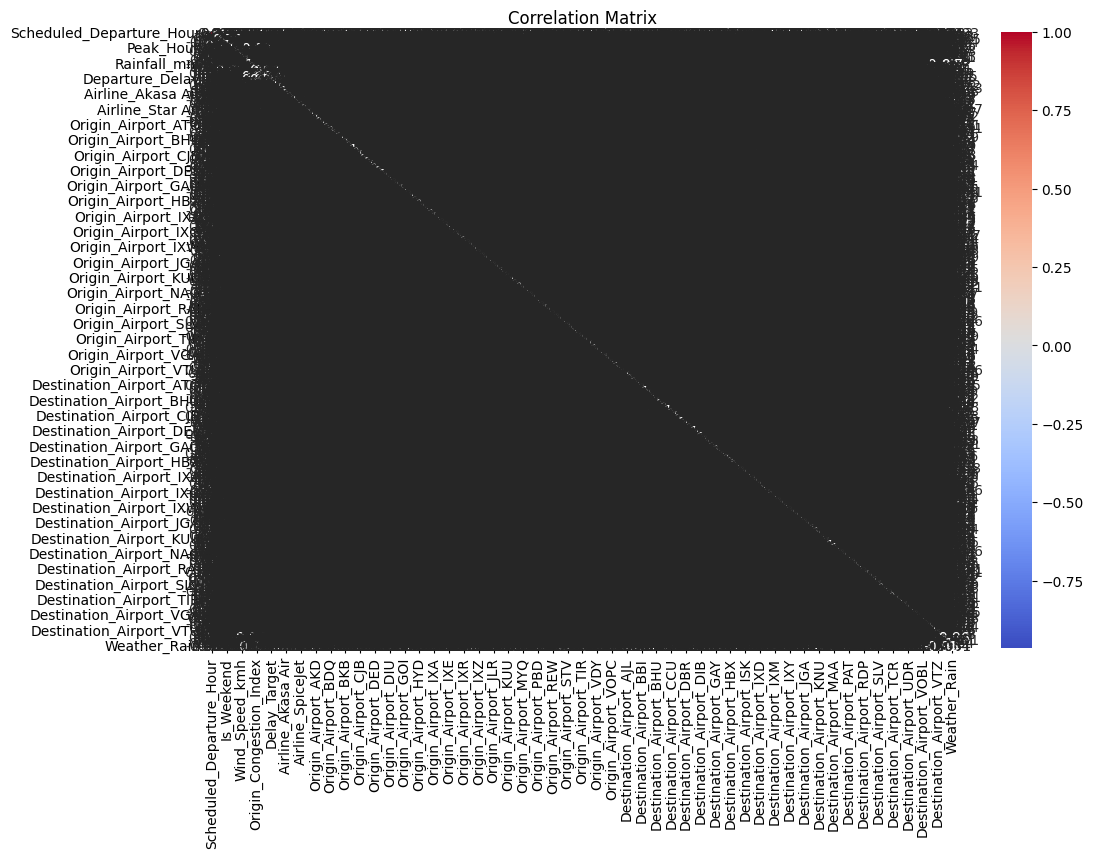

In [48]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True)
plt.title('Correlation Matrix')
plt.show()

In [64]:
from sklearn.linear_model import LogisticRegression

model_log = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

In [66]:
X.isna().sum()[X.isna().sum() > 0]

,0
Temperature_C,1
Humidity_pct,1
Wind_Speed_kmh,1
Visibility_km,1
Rainfall_mm,1
Cloud_Cover_pct,1
Origin_Congestion_Index,1
Previous_Flight_Delay_Minutes,1
Turnaround_Risk_Index,1


In [67]:
print("Total NaNs in X:", X.isna().sum().sum())

Total NaNs in X: 9


In [68]:
df = df.dropna()

X = df.drop(columns=['Delay_Target', 'Departure_Delay'])
y = df['Delay_Target']

In [69]:
X = X.fillna(X.median(numeric_only=True))

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_log.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [72]:
pred_log = model_log.predict(X_test_scaled)

In [73]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print(confusion_matrix(y_test, pred_log))
print(classification_report(y_test, pred_log))

print("ROC-AUC:", roc_auc_score(y_test, pred_log))
print("PR-AUC:", average_precision_score(y_test, pred_log))

[[ 189   65]
 [ 288 1346]]
              precision    recall  f1-score   support

         0.0       0.40      0.74      0.52       254
         1.0       0.95      0.82      0.88      1634

    accuracy                           0.81      1888
   macro avg       0.68      0.78      0.70      1888
weighted avg       0.88      0.81      0.83      1888

ROC-AUC: 0.7839199491128481
PR-AUC: 0.9383406166158879


In [74]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [75]:
model_log = Pipeline([
    ('scaler', StandardScaler()),
    ('log', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])


In [76]:
roc_auc_score(y_test, pred_log)
average_precision_score(y_test, pred_log)

np.float64(0.9383406166158879)

In [77]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(
    model_log,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(score)
print("Mean Accuracy:", score.mean())

[0.8315678  0.81620763 0.82193959 0.82829889 0.80869104]
Mean Accuracy: 0.8213409882963723


In [78]:
from sklearn.metrics import classification_report, confusion_matrix

pred_log = model_log.fit(X_train, y_train).predict(X_test)

print(confusion_matrix(y_test, pred_log))
print(classification_report(y_test, pred_log))

[[ 189   65]
 [ 288 1346]]
              precision    recall  f1-score   support

         0.0       0.40      0.74      0.52       254
         1.0       0.95      0.82      0.88      1634

    accuracy                           0.81      1888
   macro avg       0.68      0.78      0.70      1888
weighted avg       0.88      0.81      0.83      1888



In [79]:
from sklearn.metrics import roc_auc_score

pred_proba = model_log.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, pred_proba))

ROC-AUC: 0.8325518750180707


In [80]:
# F1 Score
scores = cross_val_score(model_log, X, y, cv=5, scoring='f1')
print("Mean F1:", scores.mean())

# Recall (how many frauds are detected)
scores = cross_val_score(model_log, X, y, cv=5, scoring='recall')
print("Mean Recall:", scores.mean())

# Balanced Accuracy
scores = cross_val_score(model_log, X, y, cv=5, scoring='balanced_accuracy')
print("Mean Balanced Accuracy:", scores.mean())

Mean F1: 0.8893619161390035
Mean Recall: 0.830025461694653
Mean Balanced Accuracy: 0.7977748120577635


In [81]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [82]:
model_rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [83]:
pred_rf = model_rf.predict(X_test)
pred_proba_rf = model_rf.predict_proba(X_test)[:, 1]

In [84]:
print(confusion_matrix(y_test, pred_rf))
print(classification_report(
    y_test,
    pred_rf,
    zero_division=0
))

[[ 186   68]
 [  88 1546]]
              precision    recall  f1-score   support

         0.0       0.68      0.73      0.70       254
         1.0       0.96      0.95      0.95      1634

    accuracy                           0.92      1888
   macro avg       0.82      0.84      0.83      1888
weighted avg       0.92      0.92      0.92      1888



In [85]:
print("ROC-AUC:", roc_auc_score(y_test, pred_proba_rf))

ROC-AUC: 0.8620866623618192


In [86]:
scores = cross_val_score(
    model_rf,
    X,
    y,
    cv=5,
    scoring='f1'
)

print(scores)
print("Mean F1:", scores.mean())

[0.95293756 0.95614842 0.96054254 0.95644172 0.95015385]
Mean F1: 0.9552448164847279


In [87]:
# F1 Score
scores = cross_val_score(model_rf, X, y, cv=5, scoring='f1')
print("Mean F1:", scores.mean())

# Recall (how many frauds are detected)
scores = cross_val_score(model_rf, X, y, cv=5, scoring='recall')
print("Mean Recall:", scores.mean())

# Balanced Accuracy
scores = cross_val_score(model_rf, X, y, cv=5, scoring='balanced_accuracy')
print("Mean Balanced Accuracy:", scores.mean())

Mean F1: 0.9552448164847279
Mean Recall: 0.9513842032558288
Mean Balanced Accuracy: 0.8454836717992903


In [88]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

In [89]:
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [90]:
pred_xgb = model_xgb.predict(X_test)
pred_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

In [91]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print(confusion_matrix(y_test, pred_xgb))
print(classification_report(
    y_test,
    pred_xgb,
    zero_division=0
))

print("ROC-AUC:", roc_auc_score(y_test, pred_proba_xgb))

[[ 174   80]
 [  20 1614]]
              precision    recall  f1-score   support

         0.0       0.90      0.69      0.78       254
         1.0       0.95      0.99      0.97      1634

    accuracy                           0.95      1888
   macro avg       0.92      0.84      0.87      1888
weighted avg       0.95      0.95      0.94      1888

ROC-AUC: 0.8634455806243314


In [92]:
print("ROC-AUC:", roc_auc_score(y_test, pred_proba_xgb))

ROC-AUC: 0.8634455806243314


In [93]:
scores = cross_val_score(
    model_xgb,
    X,
    y,
    cv=5,
    scoring='f1'
)

print(scores)
print("Mean F1:", scores.mean())

[0.97237237 0.96844004 0.97225573 0.97203008 0.96752856]
Mean F1: 0.97052535525241


In [94]:
# F1 Score
scores = cross_val_score(model_xgb, X, y, cv=5, scoring='f1')
print("Mean F1:", scores.mean())

# Recall (how many frauds are detected)
scores = cross_val_score(model_xgb, X, y, cv=5, scoring='recall')
print("Mean Recall:", scores.mean())

# Balanced Accuracy
scores = cross_val_score(model_xgb, X, y, cv=5, scoring='balanced_accuracy')
print("Mean Balanced Accuracy:", scores.mean())

Mean F1: 0.97052535525241
Mean Recall: 0.9878762008483234
Mean Balanced Accuracy: 0.8401292382966334


In [95]:
from sklearn.ensemble import GradientBoostingClassifier

model_gbr = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [96]:
model_gbr.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [97]:
pred_gbr = model_gbr.predict(X_test)
pred_proba_gbr = model_gbr.predict_proba(X_test)[:, 1]

In [98]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print(confusion_matrix(y_test, pred_gbr))
print(classification_report(
    y_test,
    pred_gbr,
    zero_division=0
))

print("ROC-AUC:", roc_auc_score(y_test, pred_proba_gbr))

[[ 178   76]
 [  19 1615]]
              precision    recall  f1-score   support

         0.0       0.90      0.70      0.79       254
         1.0       0.96      0.99      0.97      1634

    accuracy                           0.95      1888
   macro avg       0.93      0.84      0.88      1888
weighted avg       0.95      0.95      0.95      1888

ROC-AUC: 0.8556402336182887


In [99]:
print("ROC-AUC:", roc_auc_score(y_test, pred_proba_gbr))

ROC-AUC: 0.8556402336182887


In [100]:
scores = cross_val_score(
    model_gbr,
    X,
    y,
    cv=5,
    scoring='f1'
)

print(scores)
print("Mean F1:", scores.mean())

[0.97233915 0.96634615 0.96898525 0.96964232 0.96601504]
Mean F1: 0.9686655806756784


In [101]:
# F1 Score
scores = cross_val_score(model_gbr, X, y, cv=5, scoring='f1')
print("Mean F1:", scores.mean())

# Recall (how many frauds are detected)
scores = cross_val_score(model_gbr, X, y, cv=5, scoring='recall')
print("Mean Recall:", scores.mean())

# Balanced Accuracy
scores = cross_val_score(model_gbr, X, y, cv=5, scoring='balanced_accuracy')
print("Mean Balanced Accuracy:", scores.mean())

Mean F1: 0.9686655806756784
Mean Recall: 0.9861617151153421
Mean Balanced Accuracy: 0.8325852577429421


In [105]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=10      # start with 10 to reduce overfitting
)


In [106]:
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [110]:
pred_dt = model_dt.predict(X_test)
pred_proba_dt = model_dt.predict_proba(X_test)[:, 1]

In [111]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print(confusion_matrix(y_test, pred_dt))
print(classification_report(
    y_test,
    pred_dt,
    zero_division=0
))

print("ROC-AUC:", roc_auc_score(y_test, pred_proba_dt))

[[ 162   92]
 [  40 1594]]
              precision    recall  f1-score   support

         0.0       0.80      0.64      0.71       254
         1.0       0.95      0.98      0.96      1634

    accuracy                           0.93      1888
   macro avg       0.87      0.81      0.84      1888
weighted avg       0.93      0.93      0.93      1888

ROC-AUC: 0.7648649755683844


In [112]:
print("ROC-AUC:", roc_auc_score(y_test, pred_proba_dt))

ROC-AUC: 0.7648649755683844


In [113]:
scores = cross_val_score(
    model_dt,
    X,
    y,
    cv=5,
    scoring='f1'
)

print(scores)
print("Mean F1:", scores.mean())

[0.96211666 0.96282974 0.96207104 0.96302976 0.96108597]
Mean F1: 0.9622266327569979


In [114]:
# F1 Score
scores = cross_val_score(model_dt, X, y, cv=5, scoring='f1')
print("Mean F1:", scores.mean())

# Recall (how many frauds are detected)
scores = cross_val_score(model_dt, X, y, cv=5, scoring='recall')
print("Mean Recall:", scores.mean())

# Balanced Accuracy
scores = cross_val_score(model_dt, X, y, cv=5, scoring='balanced_accuracy')
print("Mean Balanced Accuracy:", scores.mean())

Mean F1: 0.9622266327569979
Mean Recall: 0.9795493947132318
Mean Balanced Accuracy: 0.808428395056168


In [103]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

pred_rf = model_rf.predict(X_test)
prob_rf = model_rf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, pred_rf))
print("F1:", f1_score(y_test, pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, prob_rf))
print("PR-AUC:", average_precision_score(y_test, prob_rf))

print(confusion_matrix(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Accuracy: 0.9173728813559322
Balanced Accuracy: 0.8392139477057412
F1: 0.9519704433497537
ROC-AUC: 0.8620866623618192
PR-AUC: 0.9597231471862329
[[ 186   68]
 [  88 1546]]
              precision    recall  f1-score   support

         0.0       0.68      0.73      0.70       254
         1.0       0.96      0.95      0.95      1634

    accuracy                           0.92      1888
   macro avg       0.82      0.84      0.83      1888
weighted avg       0.92      0.92      0.92      1888



In [115]:
print(X.columns.tolist())

['Scheduled_Departure_Hour', 'Scheduled_Departure_Minute', 'Day_of_Week', 'Month', 'Is_Weekend', 'Peak_Hour', 'Temperature_C', 'Humidity_pct', 'Wind_Speed_kmh', 'Visibility_km', 'Rainfall_mm', 'Cloud_Cover_pct', 'Origin_Congestion_Index', 'Previous_Flight_Delay_Minutes', 'Turnaround_Risk_Index', 'Year', 'Day', 'Airline_Air India Express', 'Airline_Akasa Air', 'Airline_Alliance Air', 'Airline_Fly91', 'Airline_IndiGo', 'Airline_SpiceJet', 'Airline_Star Air', 'Airline_Vistara', 'Origin_Airport_AJL', 'Origin_Airport_AKD', 'Origin_Airport_AMD', 'Origin_Airport_ATQ', 'Origin_Airport_BBI', 'Origin_Airport_BDQ', 'Origin_Airport_BHJ', 'Origin_Airport_BHO', 'Origin_Airport_BHU', 'Origin_Airport_BKB', 'Origin_Airport_BLR', 'Origin_Airport_BOM', 'Origin_Airport_CCU', 'Origin_Airport_CJB', 'Origin_Airport_CNN', 'Origin_Airport_COK', 'Origin_Airport_DBR', 'Origin_Airport_DED', 'Origin_Airport_DEL', 'Origin_Airport_DHM', 'Origin_Airport_DIB', 'Origin_Airport_DIU', 'Origin_Airport_DMU', 'Origin_Airpor

In [119]:
import joblib

joblib.dump(model_rf, 'flight_delay_model.pkl')

['flight_delay_model.pkl']

In [120]:
loaded_model = joblib.load('flight_delay_model.pkl')

predictions = loaded_model.predict(X_test)

print(predictions[:10])

[1. 0. 1. 1. 1. 1. 1. 1. 1. 1.]


In [124]:
import os

os.path.exists('flight_delay_model.pkl')

True